<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/Predictive_Models_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Models: Prophet





Prophet is an open-source forecasting tool developed by Facebook for time series analysis and forecasting tasks. It is designed to handle the complexities and challenges associated with forecasting data that exhibit various patterns such as trends, seasonality, and holiday effects. Prophet offers a user-friendly interface, robust modeling capabilities, and automatic feature selection, making it accessible to both beginners and experienced analysts.

In [ ]:
!pip install prophet

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from prophet.plot import plot_plotly, plot_components_plotly
from prophet import Prophet
from statsmodels.tools.eval_measures import rmse

This code fetches historical Consumer Price Index (CPI) data from FRED (Federal Reserve Economic Data) using the pandas_datareader library. It then calculates the inflation rate based on the CPI data, adds it to the DataFrame, and prepares the DataFrame for further analysis using Facebook's Prophet library by renaming columns to 'ds' (date) and 'y' (inflation rate). Finally, it plots the historical inflation rate over time.

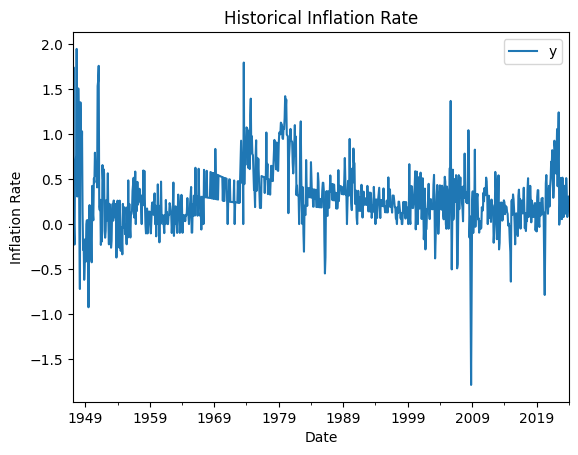

In [ ]:
# Define the start and end dates
start_date = '1947-01-01'
end_date = '2024-01-01'

# Fetch data from FRED using pandas_datareader
df = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)
df.reset_index(drop=False, inplace=True)

# Add a column for the log of CPI
df['log_cpi'] = np.log(df['CPIAUCSL'])

# Calculate the inflation rate: 100 * (log(CPI_{t}) - log(CPI_t))
h = 1
df['inflation'] = 100 * (df['log_cpi'] - df['log_cpi'].shift(h))

# Drop rows with NaN values
df.dropna(inplace=True)

# Prepare the DataFrame for Prophet (renaming columns to 'ds' and 'y')
df = df[['DATE', 'inflation']]
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

# Plot the historical inflation rate
df.plot(x='ds', y='y')
plt.title('Historical Inflation Rate')
plt.xlabel('Date')
plt.ylabel('Inflation Rate')
plt.show()


The process involves splitting the DataFrame into training and testing datasets, a crucial step for evaluating the model's performance. This split, a common practice in both machine learning and time series forecasting, enables the assessment of the model's ability to generalize to unseen data. Specifically, the training dataset encompasses the majority of historical data, while the testing dataset contains a portion of the most recent observations.

The split reserves the last 10 years of data for testing, ensuring a fair evaluation of the model's predictive accuracy. Consequently, the 'train' DataFrame comprises historical inflation rate observations used for model training. In contrast, the 'test' DataFrame contains a subset of the most recent inflation rate data, pivotal for evaluating the model's performance on unseen observations.

This meticulous train-test split methodology guarantees an unbiased assessment of the forecasting model's capabilities, enhancing its robustness in generalizing to new data.

In [ ]:
train = df.iloc[:len(df) - (12 * 10)]
test = df.iloc[len(df) - (12 * 10):]

## Make predictions

The objective here is to utilize the Prophet forecasting model to predict future inflation rates based on historical data. The model is initialized, trained using the training dataset containing historical inflation rate observations, and then utilized to generate forecasts for future time periods. The 'make_future_dataframe' function is employed to create a DataFrame representing future dates, extending the timeline beyond the historical data by 10 years. Finally, the 'predict' function is applied to generate forecasts for these future dates, providing insights into expected inflation rate trends.

In [ ]:
model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=12*10, freq='M')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp08yn1z1n/u9n4bn0y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp08yn1z1n/1w6s5pbu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=10589', 'data', 'file=/tmp/tmp08yn1z1n/u9n4bn0y.json', 'init=/tmp/tmp08yn1z1n/1w6s5pbu.json', 'output', 'file=/tmp/tmp08yn1z1n/prophet_model2vvv1rqk/prophet_model-20240521171418.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:14:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:14:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


This snippet extracts the last few rows of the forecast DataFrame, focusing on specific columns including 'ds' (dates), 'yhat' (predicted inflation rates), 'yhat_lower' (lower bound of predicted inflation rates), and 'yhat_upper' (upper bound of predicted inflation rates). These values represent the forecasted inflation rates along with their corresponding uncertainty intervals, providing insights into the model's predictions for the most recent time periods.

In [ ]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
919,2023-08-31,0.082088,-0.301983,0.487549
920,2023-09-30,-0.183792,-0.604349,0.243030
921,2023-10-31,0.006175,-0.384638,0.451670
922,2023-11-30,0.014857,-0.418818,0.437142
923,2023-12-31,0.017347,-0.398709,0.433651


## Forecast Visualization

 - Black points: Data points used for training the model.
 - Blue line: Forecast generated by the model.
 - Training portion: The section of the blue line within the black points corresponds to the training portion of the dataset.
 - Testing portion: The section of the blue line without black points represents the testing portion.
 - Light blue area: Confidence intervals indicating the uncertainty of the forecast.

In [ ]:
plot_plotly(model, forecast)

Trend: This component shows the overall trend in the time series data. It indicates the long-term direction in which the series is moving, whether it's increasing, decreasing, or remaining relatively stable over time.

Yearly Seasonality: This component captures patterns or fluctuations in the data that occur on an annual basis. It helps identify any regular patterns or cycles that repeat each year, such as seasonal fluctuations in sales, demand, or other phenomena.

In [ ]:
plot_components_plotly(model, forecast)

## Model Evaluation

The objective of this code is to evaluate the accuracy of the Prophet model's predictions by calculating the Root Mean Squared Error (RMSE) between the forecasted values and the actual values in the test dataset.

By comparing the RMSE to the mean value of the test dataset, analysts can assess the performance of the forecasting model. A lower RMSE indicates that the model's predictions are closer to the actual values in the test dataset, while a higher RMSE suggests that the model's predictions deviate further from the actual values.

In [ ]:
predictions = forecast.iloc[-120:]['yhat']
print("Root Mean Squared Error between actual and predicted values:", rmse(predictions, test['y']))
print("Mean Value of Test Dataset:", test['y'].mean())

Root Mean Squared Error between actual and predicted values: 0.36497257851359927
Mean Value of Test Dataset: 0.22895446344169365
